# Day 3: Linear Regression — Solutions

**Warning:** Try to complete the exercises in `demos/05_SupervisedML_LinearRegression.ipynb` on your own before looking at these solutions!

---

## Setup

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.formula.api import ols

sns.set_theme()
print("✓ Libraries imported!")

✓ Libraries imported!


---

## Task 1: Visualize a Linear Relationship

### Solution

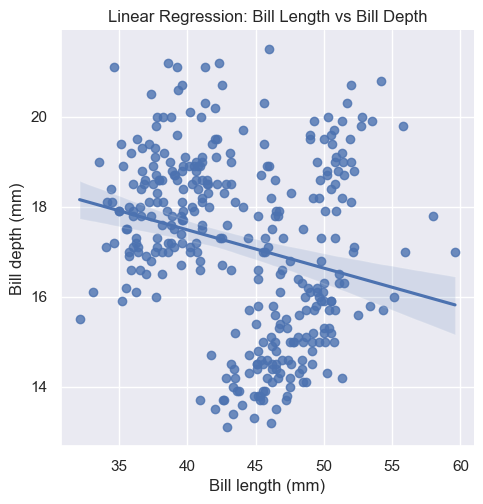

Notice: The regression line slopes downward (negative correlation).
But as we'll see with Simpson's Paradox, this is misleading!


In [11]:
penguins = sns.load_dataset('penguins')

g = sns.lmplot(
    data=penguins,
    x='bill_length_mm',
    y='bill_depth_mm'
)

g.set_axis_labels('Bill length (mm)', 'Bill depth (mm)')
plt.title('Linear Regression: Bill Length vs Bill Depth')
plt.show()

print("Notice: The regression line slopes downward (negative correlation).")
print("But as we'll see with Simpson's Paradox, this is misleading!")

### Simpson's Paradox

The plot above shows a **negative** correlation overall — longer bills seem to have shallower depth. But this is misleading!

**Simpson's Paradox** occurs when a trend that appears in aggregated data **reverses** when the data is split into subgroups. Here, the three penguin species form natural subgroups with different bill shapes:

- **Adelie**: short bills, deep bills
- **Chinstrap**: medium bills, deep bills  
- **Gentoo**: long bills, shallow bills

When we look at the data **overall**, the species differences dominate and create a false negative trend. But **within each species**, longer bills actually correlate with deeper bills (positive correlation).

Let's visualize this by coloring the data by species:

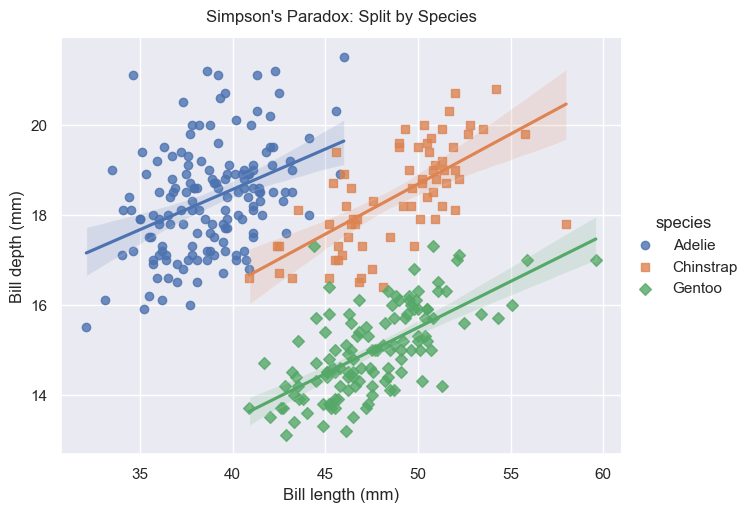

Key observation:
- Overall trend (previous plot): NEGATIVE correlation
- Within each species:           POSITIVE correlation

This is Simpson's Paradox in action!
The species act as a confounding variable that reverses the apparent relationship.


In [12]:
# Split by species: each species gets its own regression line
g = sns.lmplot(
    data=penguins,
    x='bill_length_mm',
    y='bill_depth_mm',
    hue='species',
    markers=['o', 's', 'D'],
    height=5,
    aspect=1.3
)

g.set_axis_labels('Bill length (mm)', 'Bill depth (mm)')
plt.title("Simpson's Paradox: Split by Species", y=1.02)
plt.show()

print("Key observation:")
print("- Overall trend (previous plot): NEGATIVE correlation")
print("- Within each species:           POSITIVE correlation")
print("\nThis is Simpson's Paradox in action!")
print("The species act as a confounding variable that reverses the apparent relationship.")

**Explanation:**
- `sns.lmplot` creates a scatter plot with an automatic linear regression fit line
- The first plot (without `hue`) shows the **overall** trend: a misleading negative correlation
- The second plot (with `hue='species'`) reveals the **true** relationship: each species individually shows a positive correlation
- This is **Simpson's Paradox** — a confounding variable (species) reverses the apparent direction of a relationship
- **Takeaway for ML:** Always explore subgroups in your data before fitting models. A single regression line across mixed populations can be completely wrong!

---

## Exercise 1: Melbourne Housing Price Prediction

### Solution

In [13]:
# Step 1: Load and explore
melb = pd.read_csv('../datasets/melb_data.csv')
print(f"Dataset: {melb.shape[0]} houses, {melb.shape[1]} columns")
print(f"\nMissing values (top 5):")
print(melb.isnull().sum().sort_values(ascending=False).head())

Dataset: 13580 houses, 21 columns

Missing values (top 5):
BuildingArea    6450
YearBuilt       5375
CouncilArea     1369
Car               62
Suburb             0
dtype: int64


In [14]:
# Step 2: Select features and prepare data
feature_cols = ['Rooms', 'Distance', 'Bathroom', 'Landsize', 'BuildingArea']

# Drop rows with missing values in our selected columns
melb_clean = melb[feature_cols + ['Price']].dropna()
print(f"Samples after dropping NaN: {len(melb_clean)} (dropped {len(melb) - len(melb_clean)})")

X_melb = melb_clean[feature_cols]
y_melb = melb_clean['Price']

# Split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_melb, y_melb, test_size=0.2, random_state=42
)

print(f"Training: {len(X_train_m)}, Test: {len(X_test_m)}")

Samples after dropping NaN: 7130 (dropped 6450)
Training: 5704, Test: 1426


In [15]:
# Step 3 & 4: Train and evaluate
model_melb = LinearRegression()
model_melb.fit(X_train_m, y_train_m)

y_pred_m = model_melb.predict(X_test_m)

mae = mean_absolute_error(y_test_m, y_pred_m)
rmse = np.sqrt(mean_squared_error(y_test_m, y_pred_m))
r2 = r2_score(y_test_m, y_pred_m)
r2_train = r2_score(y_train_m, model_melb.predict(X_train_m))

print("=" * 50)
print("MELBOURNE HOUSING MODEL")
print("=" * 50)
print(f"MAE:        ${mae:,.0f}")
print(f"RMSE:       ${rmse:,.0f}")
print(f"R² (test):  {r2:.4f}")
print(f"R² (train): {r2_train:.4f}")

print(f"\nCoefficients:")
for feat, coef in zip(feature_cols, model_melb.coef_):
    print(f"  {feat:<15s}: {coef:>12,.2f}")
print(f"  {'Intercept':<15s}: {model_melb.intercept_:>12,.2f}")

MELBOURNE HOUSING MODEL
MAE:        $352,557
RMSE:       $545,135
R² (test):  0.3628
R² (train): 0.4294

Coefficients:
  Rooms          :   318,240.64
  Distance       :   -38,018.14
  Bathroom       :   233,096.10
  Landsize       :        16.56
  BuildingArea   :        28.15
  Intercept      :   132,843.23


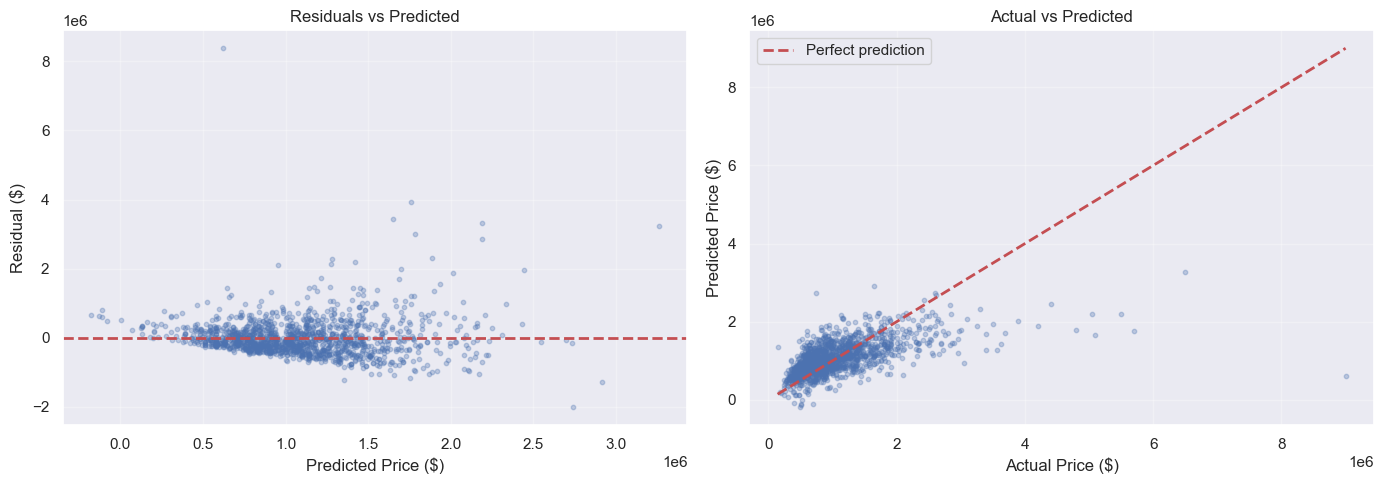

Observations:
- Residuals show a fan pattern (spread increases for higher prices)
- This suggests heteroscedasticity (non-constant variance)
- The model struggles with very expensive houses
- A log-transform of Price could help address this


In [16]:
# Step 5: Residual plots
residuals = y_test_m - y_pred_m

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred_m, residuals, alpha=0.3, s=10)
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Price ($)')
axes[0].set_ylabel('Residual ($)')
axes[0].set_title('Residuals vs Predicted')
axes[0].grid(True, alpha=0.3)

# Actual vs Predicted
axes[1].scatter(y_test_m, y_pred_m, alpha=0.3, s=10)
axes[1].plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()],
             'r--', lw=2, label='Perfect prediction')
axes[1].set_xlabel('Actual Price ($)')
axes[1].set_ylabel('Predicted Price ($)')
axes[1].set_title('Actual vs Predicted')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Observations:")
print("- Residuals show a fan pattern (spread increases for higher prices)")
print("- This suggests heteroscedasticity (non-constant variance)")
print("- The model struggles with very expensive houses")
print("- A log-transform of Price could help address this")

**Explanation:**
- We used 5 numerical features that are commonly predictive of house prices
- `dropna()` removes rows where any of our selected columns has missing data
- The R² is moderate, meaning our simple features explain some but not all price variation
- The residual analysis reveals non-constant variance — the model is worse for expensive houses
- Adding categorical features (suburb, property type) or using non-linear models could improve predictions

---

## Exercise 2: Feature Selection with Statsmodels

### Solution

In [17]:
tips = sns.load_dataset('tips')

# Full model
full_formula = 'tip ~ total_bill + size + smoker + sex + day + time'
result_full = ols(formula=full_formula, data=tips).fit()

print("FULL MODEL")
print("=" * 50)
print(f"R² = {result_full.rsquared:.4f}, Adj. R² = {result_full.rsquared_adj:.4f}")
print(f"\nP-values:")
for name, pval in result_full.pvalues.items():
    sig = '✓ significant' if pval < 0.05 else '✗ NOT significant'
    print(f"  {name:<20s}: p = {pval:.4f}  {sig}")

FULL MODEL
R² = 0.4701, Adj. R² = 0.4520

P-values:
  Intercept           : p = 0.0218  ✓ significant
  smoker[T.No]        : p = 0.5561  ✗ NOT significant
  sex[T.Female]       : p = 0.8190  ✗ NOT significant
  day[T.Fri]          : p = 0.6804  ✗ NOT significant
  day[T.Sat]          : p = 0.9310  ✗ NOT significant
  day[T.Sun]          : p = 0.7721  ✗ NOT significant
  time[T.Dinner]      : p = 0.8783  ✗ NOT significant
  total_bill          : p = 0.0000  ✓ significant
  size                : p = 0.0505  ✗ NOT significant


In [18]:
# Simplified model: keep only significant features
simple_formula = 'tip ~ total_bill + size'
result_simple = ols(formula=simple_formula, data=tips).fit()

print("\nSIMPLIFIED MODEL")
print("=" * 50)
print(f"R² = {result_simple.rsquared:.4f}, Adj. R² = {result_simple.rsquared_adj:.4f}")
print(f"\nP-values:")
for name, pval in result_simple.pvalues.items():
    print(f"  {name:<15s}: p = {pval:.4f}")

print(f"\nComparison:")
print(f"  Full model Adj. R²:       {result_full.rsquared_adj:.4f}")
print(f"  Simplified model Adj. R²:  {result_simple.rsquared_adj:.4f}")
print(f"\nThe simplified model has nearly the same Adj. R² with fewer features.")
print(f"Removing non-significant features reduces complexity without losing accuracy.")


SIMPLIFIED MODEL
R² = 0.4679, Adj. R² = 0.4635

P-values:
  Intercept      : p = 0.0006
  total_bill     : p = 0.0000
  size           : p = 0.0249

Comparison:
  Full model Adj. R²:       0.4520
  Simplified model Adj. R²:  0.4635

The simplified model has nearly the same Adj. R² with fewer features.
Removing non-significant features reduces complexity without losing accuracy.


**Explanation:**
- In the full model, `smoker`, `sex`, `day`, and `time` all have p-values > 0.05, meaning they are not statistically significant predictors of tip
- Only `total_bill` and `size` are significant predictors
- The simplified model with just these two features has nearly identical Adjusted R², confirming that the dropped features added no real predictive power
- Adjusted R² (not plain R²) is the right metric for comparing models with different numbers of features, because it penalizes unnecessary complexity

---

## Exercise 3: Penguin Body Mass — Multiple Features

### Solution

In [19]:
# Prepare multi-feature data
penguins_clean = penguins.dropna(subset=['flipper_length_mm', 'bill_length_mm', 'bill_depth_mm', 'body_mass_g'])

feature_names = ['flipper_length_mm', 'bill_length_mm', 'bill_depth_mm']
X_multi = penguins_clean[feature_names].values
y_multi = penguins_clean['body_mass_g'].values

# Split
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

# Train multi-feature model
model_multi = LinearRegression()
model_multi.fit(X_train_multi, y_train_multi)
y_pred_multi = model_multi.predict(X_test_multi)

# Also train single-feature model for comparison
X_single = penguins_clean[['flipper_length_mm']].values
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_single, y_multi, test_size=0.2, random_state=42
)
model_single = LinearRegression()
model_single.fit(X_train_s, y_train_s)
y_pred_single = model_single.predict(X_test_s)

# Compare
r2_single = r2_score(y_test_s, y_pred_single)
r2_multi = r2_score(y_test_multi, y_pred_multi)

print(f"Single feature (flipper_length only):  R² = {r2_single:.4f}")
print(f"Multiple features (3 features):        R² = {r2_multi:.4f}")
print(f"Improvement:                           +{r2_multi - r2_single:.4f}")

print(f"\nFeature coefficients:")
for feat, coef in zip(feature_names, model_multi.coef_):
    print(f"  {feat:<22s}: {coef:>8.2f} g per mm")

print(f"\nAdding bill dimensions improves the prediction because they capture")
print(f"additional body size information that flipper length alone misses.")

Single feature (flipper_length only):  R² = 0.7820
Multiple features (3 features):        R² = 0.7878
Improvement:                           +0.0057

Feature coefficients:
  flipper_length_mm     :    48.67 g per mm
  bill_length_mm        :     4.01 g per mm
  bill_depth_mm         :    10.92 g per mm

Adding bill dimensions improves the prediction because they capture
additional body size information that flipper length alone misses.


**Explanation:**
- Adding `bill_length_mm` and `bill_depth_mm` improves R² because these features carry additional information about penguin body size
- The coefficient for each feature tells us how much body mass changes per 1mm increase in that measurement (holding others constant)
- `flipper_length_mm` has the largest coefficient, confirming it's the strongest single predictor
- In multiple regression, coefficients are adjusted for the other features, so they represent the *unique* contribution of each feature

---

## Summary

In these solutions you practiced:

✓ Visualizing linear relationships with `sns.lmplot`  
✓ Building a multi-feature regression model for house price prediction  
✓ Interpreting residual plots and identifying heteroscedasticity  
✓ Using statsmodels p-values for feature selection  
✓ Comparing single-feature vs. multi-feature regression models  

---